In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Model

np.random.seed(123)
tf.random.set_seed(123)

In [3]:
from sklearn.metrics import mean_absolute_percentage_error

In [4]:
import os
os.chdir(r'G:\My Drive\Study\Time Series Analysis Udemy\Data\time series analysis forecasting')
os.getcwd()

'G:\\My Drive\\Study\\Time Series Analysis Udemy\\Data\\time series analysis forecasting'

In [5]:
df = pd.read_csv('airline_passengers.csv', index_col= 'Month', parse_dates = True)

In [6]:
df['LogPassengers'] = np.log(df['Passengers'])

In [7]:
Ntest=12
train = df[:-Ntest]
test = df[-Ntest:]

In [8]:
train_idx = df.index <= train.index[-1]
test_idx = ~train_idx

In [9]:
df['DiffLogPassengers'] = df['LogPassengers'].diff()

In [10]:
''' ANN might be already powerful enough that we dont really require differencing - it is just that we choose to use differencing'''

' ANN might be already powerful enough that we dont really require differencing - it is just that we choose to use differencing'

In [12]:
series = df['DiffLogPassengers'].dropna().to_numpy()

T = 10
X = []
Y = []

for t in range(len(series)-T):
    x = series[t:t+T]
    y = series[t+T]
    X.append(x)
    Y.append(y)

X = np.array(X).reshape(-1,T)
Y = np.array(Y)
N = len(X)
print("X.shape:", X.shape,"Y.shape:", Y.shape)

X.shape: (133, 10) Y.shape: (133,)


In [15]:
''' as mentioned in the previous notebooks as well, this method is not correct due to data leakage happenning in test set.
.the label of the 1st row of test set is present as the last feature in the new row of the test set'''

' as mentioned in the previous notebooks as well, this method is not correct due to data leakage happenning in test set.\n.the label of the 1st row of test set is present as the last feature in the new row of the test set'

In [17]:
Xtrain, Ytrain = X[:-Ntest], Y[:-Ntest]
Xtest, Ytest = X[-Ntest:], Y[-Ntest:] 

In [20]:
''' the label of the 1st row of test set is present as the last feature in the new row of the test set.
this could lead to much better performance in the test set giving false impression that model performs very well in the test set'''

' the label of the 1st row of test set is present as the last feature in the new row of the test set.\nthis could lead to much better performance in the test set giving false impression that model performs very well in the test set'

In [31]:
# Basic ANN
i = Input(shape = (T,))
x = Dense(32, activation ='relu')(i)
x = Dense(1)(x) # keras defaults to linear activation function meaning no activation
model = Model(i,x)

model.compile(loss = 'mse', optimizer = 'adam', metrics = ['mae'])

In [32]:
r = model.fit(
    Xtrain,
    Ytrain,
    epochs = 100,
    validation_data = (Xtest, Ytest)
)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - loss: 0.0199 - mae: 0.1121 - val_loss: 0.0189 - val_mae: 0.1082
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0178 - mae: 0.1056 - val_loss: 0.0175 - val_mae: 0.1037
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0162 - mae: 0.1008 - val_loss: 0.0165 - val_mae: 0.1007
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0149 - mae: 0.0968 - val_loss: 0.0156 - val_mae: 0.0980
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0138 - mae: 0.0933 - val_loss: 0.0148 - val_mae: 0.0952
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0128 - mae: 0.0897 - val_loss: 0.0141 - val_mae: 0.0927
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0118 - mae: 0.0864 - val_loss: 0.0135 - val_mae: 0.0906
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0110 - mae: 0.0830 - val_loss: 0.0130 - val_mae: 0.0891
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0102 - mae: 

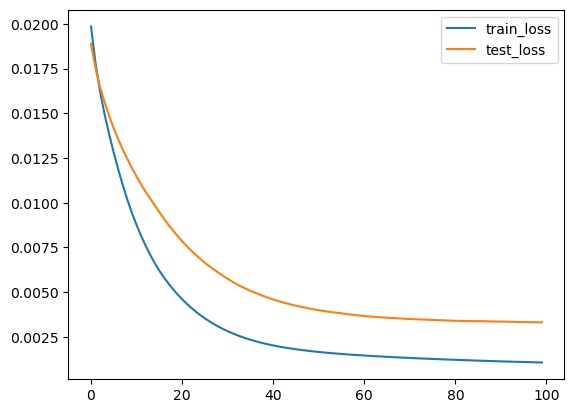

In [33]:
plt.plot(r.history['loss'], label = 'train_loss')
plt.plot(r.history['val_loss'], label = 'test_loss')
plt.legend()

In [35]:
train_idx[:T+1] = False # since first T+1 values non predictable

In [37]:
Ptrain = model.predict(Xtrain).flatten()
Ptest = model.predict(Xtest).flatten()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


In [39]:
df.loc[train_idx, 'Diff ANN Train Prediction'] = Ptrain
df.loc[test_idx, 'Diff ANN Test Prediction'] = Ptest

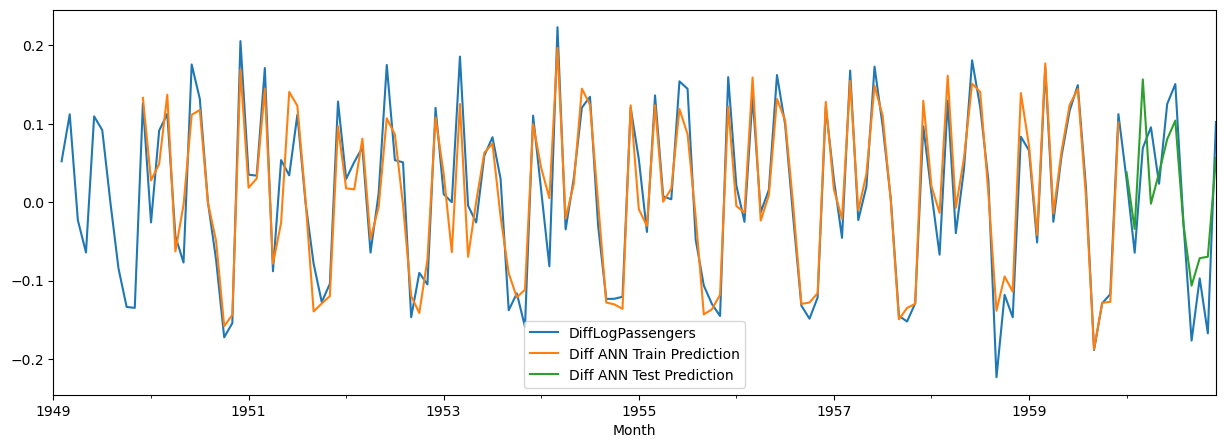

In [40]:
cols = ['DiffLogPassengers','Diff ANN Train Prediction','Diff ANN Test Prediction'] 
df[cols].plot(figsize=(15,5));

In [42]:
''' looks pretty accurate but the above is 1 step prediction - and also there is an issue with the data leakage in test here - as explained earlier'''

' looks pretty accurate but the above is 1 step prediction - and also there is an issue with the data leakage in test here - as explained earlier'

In [43]:
df['ShiftLogPassengers'] = df['LogPassengers'].shift(1)
prev = df['ShiftLogPassengers']

In [44]:
last_train = train.iloc[-1]['LogPassengers']

In [45]:
df.loc[train_idx, '1step_train'] = prev[train_idx] + Ptrain
df.loc[test_idx, '1step_test'] = prev[test_idx] + Ptest

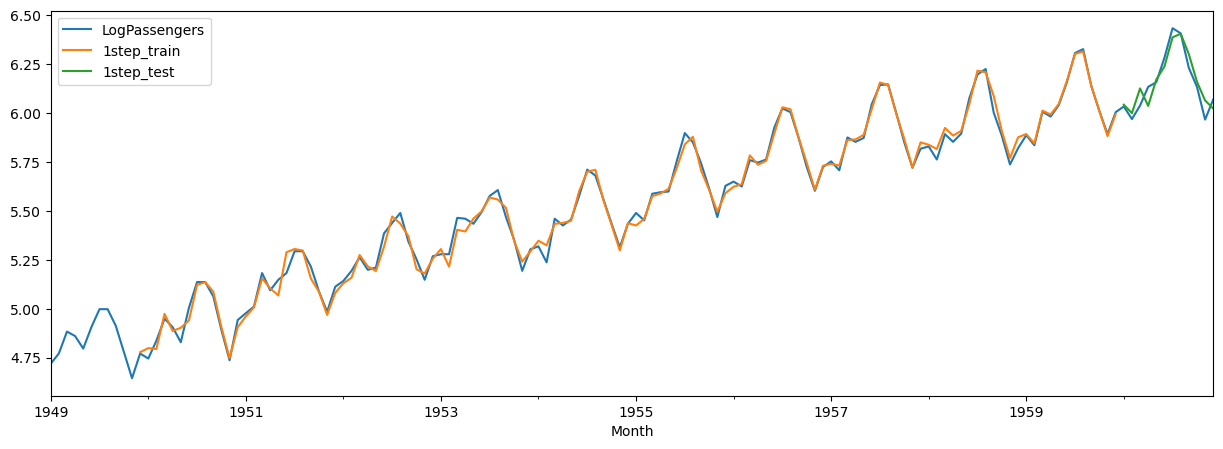

In [47]:
df[['LogPassengers','1step_train','1step_test']].plot(figsize =(15,5));

In [48]:
'''looks good but explained earlier that this is not the correct method'''

'looks good but explained earlier that this is not the correct method'

In [51]:
#multistep forecast
multistep_predictions = []
last_x = Xtest[0]

while len(multistep_predictions) < Ntest:
    p = model.predict(last_x.reshape(1,-1))[0]
    multistep_predictions.append(p)

    last_x = np.roll(last_x, -1)
    last_x[-1] = p

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


C:\Users\VARUN\AppData\Local\Temp\ipykernel_14192\44270791.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  last_x[-1] = p


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


In [52]:
df.loc[test_idx, 'multistep'] = last_train + np.cumsum(multistep_predictions)

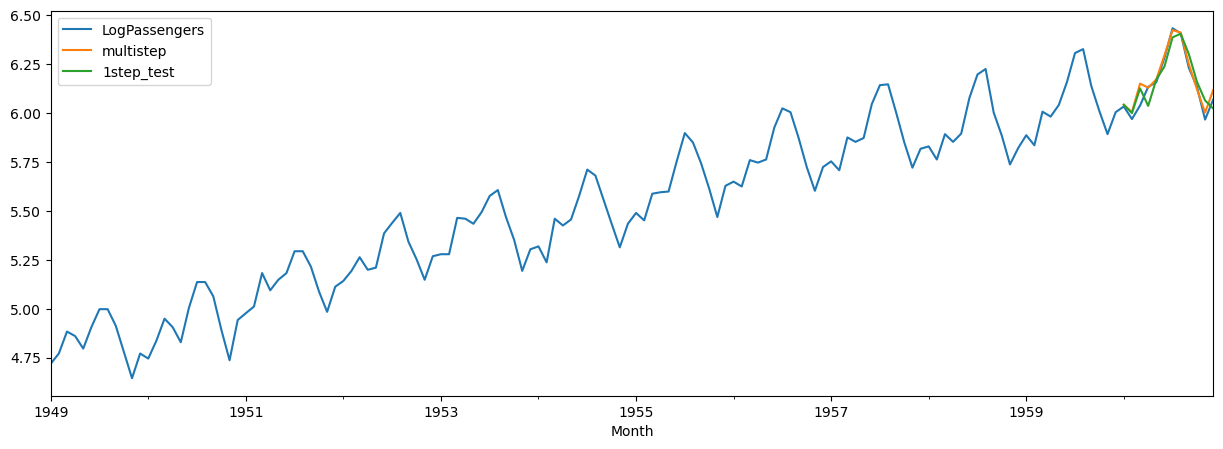

In [53]:
df[['LogPassengers','multistep','1step_test']].plot(figsize =(15,5));

In [55]:
'''just as good as one step. this is the correct way since test data labels are not leaked at all.
Also notice that we are not training new model. and despite this, we are getting good results, that means
that even in the training data when labels are leaked as features in the next row, model is not taking that into consideration and
genuinely learning patterns'''

'just as good as one step. this is the correct way since test data labels are not leaked at all.\nAlso notice that we are not training new model. and despite this, we are getting good results, that means\nthat even in the training data when labels are leaked as features in the next row, model is not taking that into consideration and\ngenuinely learning patterns'

In [59]:
# multi output supervised 
Tx = T
Ty = Ntest
X = []
Y = []

for t in range(len(series) - Tx -Ty + 1):
    x = series[t:t+Tx]
    X.append(x)
    y = series[t+Tx:t+Tx+Ty] 
    Y.append(y)

X = np.array(X).reshape(-1, Tx)
Y = np.array(Y).reshape(-1, Ty)
N = len(X)
print("X.shape",X.shape, "Y.shape", Y.shape)

X.shape (122, 10) Y.shape (122, 12)


In [60]:
Xtrain_m, Ytrain_m = X[:-1], Y[:-1]
Xtest_m, Ytest_m = X[-1:], Y[-1:]

In [62]:
i = Input(shape = (Tx,))
x = Dense(32, activation = 'relu')(i)
x = Dense(Ty)(x) # now has size Ty"
model = Model(i,x)

In [64]:
model.compile(loss='mse', optimizer='adam')

In [66]:
r = model.fit(
    Xtrain_m,
    Ytrain_m,
    epochs = 100,
    validation_data = (Xtest_m, Ytest_m)
)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - loss: 0.0151 - mae: 0.1016 - val_loss: 0.0118 - val_mae: 0.0962
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0141 - mae: 0.0984 - val_loss: 0.0112 - val_mae: 0.0942
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0132 - mae: 0.0956 - val_loss: 0.0107 - val_mae: 0.0925
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0125 - mae: 0.0931 - val_loss: 0.0103 - val_mae: 0.0909
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0119 - mae: 0.0908 - val_loss: 0.0099 - val_mae: 0.0893
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0113 - mae: 0.0888 - val_loss: 0.0095 - val_mae: 0.0876
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0109 - mae: 0.0869 - val_loss: 0.0091 - val_mae: 0.0860
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0104 - mae: 0.0851 - val_loss: 0.0088 - val_mae: 0.0843
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0100 - mae:

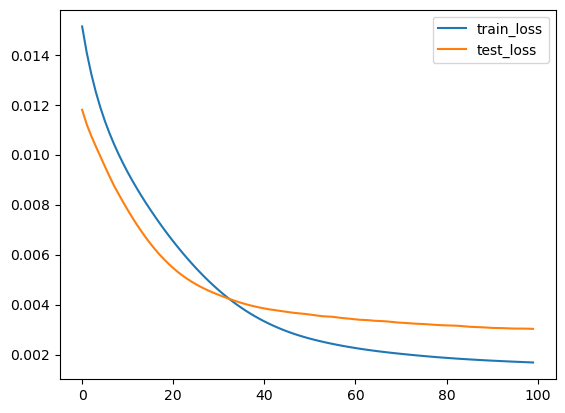

In [68]:
plt.plot(r.history['loss'], label = 'train_loss')
plt.plot(r.history['val_loss'], label = 'test_loss')
plt.legend();

In [80]:
Ptrain = model.predict(Xtrain_m)
Ptest = model.predict(Xtest_m)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


In [81]:
Ptrain.shape, Ptest.shape

((121, 12), (1, 12))

In [82]:
Ptrain

array([[ 0.08427055,  0.06515092,  0.04138687, ..., -0.09286447,
        -0.1308144 , -0.14245383],
       [ 0.05740871, -0.00238422,  0.12980193, ..., -0.12720962,
        -0.11585332,  0.09854556],
       [ 0.01217274,  0.11781983, -0.02282558, ..., -0.1114898 ,
         0.11203347,  0.02792654],
       ...,
       [-0.12179941, -0.13860606,  0.07367913, ...,  0.1309794 ,
         0.01050923, -0.14963722],
       [-0.12652251,  0.11523306,  0.05170471, ...,  0.01564179,
        -0.17879394, -0.15777765],
       [ 0.09817568,  0.0570976 , -0.05031526, ..., -0.14721787,
        -0.10587012, -0.11959786]], dtype=float32)

In [83]:
Ptrain = Ptrain[:,0] # keeping the closest predictions closer to current time since we believe it to be more accurate

In [84]:
# this is how the original Ptrain was - we just took the 1st column
# y1, y2, y3
# y2, y3, y4
# y3, y4, y5

In [85]:
Ptest

array([[ 0.01778761, -0.0241951 ,  0.16447473, -0.0346309 ,  0.05350061,
         0.14244413,  0.12734452,  0.01088981, -0.1731093 , -0.16442248,
        -0.14068165,  0.11706076]], dtype=float32)

In [86]:
Ptest[0] # just grabbing the 0th row - no more rows since test has only 1 row of data

array([ 0.01778761, -0.0241951 ,  0.16447473, -0.0346309 ,  0.05350061,
        0.14244413,  0.12734452,  0.01088981, -0.1731093 , -0.16442248,
       -0.14068165,  0.11706076], dtype=float32)

In [87]:
Ptest = Ptest[0]

In [88]:
df.loc[test_idx, 'multioutput'] = last_train + np.cumsum(Ptest)

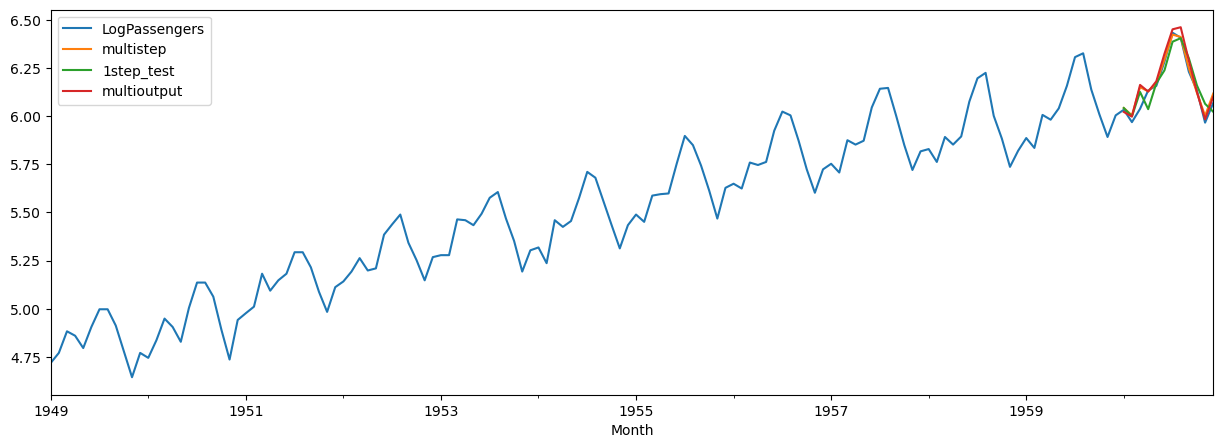

In [89]:
df[['LogPassengers','multistep','1step_test','multioutput']].plot(figsize =(15,5));

In [90]:
''' looks like multioutput is not that great- incremental was better like multistep and one step'''

' looks like multioutput is not that great- incremental was better like multistep and one step'

In [ ]:
test_log_pass = df.iloc[-Ntest:]['LogPassengers']
mape1 =  mean_absolute_percentage_error(test_log_pass, df.loc[test_idx, 'multistep'])
mape2 =  mean_absolute_percentage_error(test_log_pass, df.loc[test_idx, 'multioutput'])
print("multistep MAPE:", mape1)
print("multioutput MAPE:", mape2)